In [1]:
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset, Dataset,random_split
from torchvision.datasets import DatasetFolder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score
import random
from tqdm import tqdm
import matplotlib.pyplot as plt


n_sensors=13
decimals=1
epochs=20
batch_size=1
lr=1e-2
spf = 0.1  # reciprocal of frames per second
fc_hidden=128
accumulation_steps = 8
eps = 1e-6

# set threshold for minimum observations per sensor (change as needed)
min_obs = 10

display_interval = 10 # Display interval for training progress

#Try unet as autoencoder and decoder, have interpolated sequence as input, as in, regular input sequence padded with nan at desired timestamps

In [2]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)

In [4]:
raw_df = pd.read_csv("E:/CoDaS Project/Radar/C3/radar_merged_data.csv")
raw_df['timestamp'] = raw_df['timestamp'].round(decimals)  # Round timestamps to the specified number of decimal places for consistency

In [5]:
# Set sensor columns to NaN if they have insufficient observations for each user and emotion
for (u, e), idx in raw_df.groupby(['user_id', 'emotion']).groups.items():
    for s in range(n_sensors):
        observed = raw_df.loc[idx, f'x_{s}'].count()
        if observed < min_obs and observed > 0:  # if there are some observations but not enough
            #print(f"User {u}, Emotion {e}, Sensor {s} has insufficient data, only {observed} observations. Setting to NaN.")
            raw_df.loc[idx,[f'x_{s}', f'y_{s}', f'z_{s}']] = np.nan

# Drop empty rows after setting insufficient sensor data to NaN
raw_df = raw_df.set_index(['user_id', 'emotion', 'timestamp']).dropna(how='all').reset_index()

In [6]:
le = LabelEncoder()
le.fit(raw_df['emotion'].unique())
n_classes = len(le.classes_)

In [7]:
unique_users = raw_df['user_id'].unique()
train_users, test_users = train_test_split(unique_users, test_size=int(0.2*(len(unique_users))), random_state=42)
train_users, valid_users = train_test_split(train_users, test_size=int(0.2*(len(unique_users))), random_state=42)
train_df, test_df = raw_df[raw_df['user_id'].isin(train_users)], raw_df[raw_df['user_id'].isin(test_users)]
valid_df = raw_df[raw_df['user_id'].isin(valid_users)]

In [8]:
def train_and_predict_spline(sequence, target_ts, n_sensors=13):

    target_ts = target_ts.reshape(-1, 1)

    preds = np.zeros((len(target_ts), n_sensors,3))
    

    for j in range(n_sensors):
        sensor_seq = sequence[['timestamp',f'x_{j}',f'y_{j}',f'z_{j}']].dropna()
        if len(sensor_seq)<2:
            continue
        x = sensor_seq['timestamp'].to_numpy().reshape(-1, 1)
        y = sensor_seq.drop(columns = 'timestamp').to_numpy()

        pipe = make_pipeline(SplineTransformer(n_knots=4, degree=3), Ridge(alpha=1e-3))

        pipe.fit(x, y)
        preds[:, j] = pipe.predict(target_ts)


    preds = preds.reshape(-1,3*n_sensors)

    return preds

In [9]:
def process_input_sequence(raw_sequence, target_index):
    #raw_sequence = raw_sequence.sort_values("timestamp")
    # mask for each sensor: True if observed else false
    sensor_mask = raw_sequence.drop(columns=['timestamp']).notna().to_numpy()[:,::3]

    timestamps = raw_sequence["timestamp"].to_numpy()
    target_ts = timestamps[target_index]
    spline_preds = train_and_predict_spline(raw_sequence, target_ts)

    raw_sequence.iloc[target_index, 1:] = spline_preds

    filled_sequence = raw_sequence.ffill().bfill()
    

    filled_sequence = np.concatenate([filled_sequence, sensor_mask],axis=-1)
    filled_sequence = torch.tensor(filled_sequence, dtype=torch.float32)

    timestamps = torch.tensor(timestamps, dtype=torch.float32)

    return filled_sequence, timestamps, spline_preds

def process_target_sequence(target_values, spline_preds):
    #target_values = target_values.sort_values("timestamp")
    target_timestamps = target_values['timestamp'].values

    target_values = target_values.drop(columns=['timestamp'])
    #target_values = (target_values - input_mean)# / (input_std + eps)

    target_mask = target_values.notna().values

    target_values = target_values.fillna(0).values  # Fill NaN values with 0 for processing

    target_values-= spline_preds
    
    # Convert to torch tensor
    target_values = torch.tensor(target_values, dtype=torch.float32)
    target_mask = torch.tensor(target_mask, dtype=torch.bool)
    target_timestamps = torch.tensor(target_timestamps, dtype=torch.float32)
    
    return target_timestamps, target_values, target_mask

In [10]:
class RadarSequenceDataset(Dataset):
    def __init__(self, df,test=False):
        """
        Args:
            df: DataFrame with radar data
            test: Boolean indicating if the dataset is for testing
        """
        # Split data
        self.df = df
        self.experiments = df.index.unique()
        self.test = test
    
    def __len__(self):
        return len(self.experiments)
    
    def __getitem__(self, idx):
        experiment = self.experiments[idx]
        user_id, emotion = experiment
        experiment_data = self.df.loc[experiment].groupby("timestamp", as_index=False).mean()

        t_max = experiment_data["timestamp"].max()
        t_min = experiment_data["timestamp"].min()
        experiment_data["timestamp"] = (experiment_data["timestamp"] - t_min) / (t_max - t_min)  # Normalize timestamps to [0, 1]
        p = random.uniform(0.1, 0.3)
        # Split into input and target sequences
        if not self.test:
            input_index, target_index = train_test_split(experiment_data.index, test_size=p)
        else:
            input_index, target_index = train_test_split(experiment_data.index, test_size=0.2, random_state=42)

        target_index = target_index.sort_values()
        
        target_sequence = experiment_data.iloc[target_index]
        input_sequence = experiment_data.copy()
        input_sequence.iloc[target_index,1:] = np.nan  # Set the target indices in the input sequence to NaN for the features (not timestamps)
        # Process using existing function
        input_sequence, input_timestamps, spline_preds = process_input_sequence(input_sequence, target_index)
        target_timestamp, target_sequence, target_mask = process_target_sequence(target_sequence, spline_preds)
        target_index = torch.tensor(target_index, dtype=torch.int32)
        
        return (input_sequence, input_timestamps, spline_preds), (target_index, target_sequence, target_mask), emotion


# Create train and test datasets
train_dataset = RadarSequenceDataset(train_df.set_index(['user_id','emotion']))
valid_dataset = RadarSequenceDataset(valid_df.set_index(['user_id','emotion']), test=True)

test_dataset = RadarSequenceDataset(test_df.set_index(['user_id','emotion']), test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [11]:
# Create model
input_channels = n_sensors*4 + 1
hidden_channels = 128  # hyperparameter, we can pick whatever we want for this
output_channels = n_sensors*3  # e.g. to perform 10-way multiclass classification
    
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.ReLU(),

            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.MaxPool1d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose1d(
            in_channels,
            in_channels // 2,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        diff = x2.size(-1) - x1.size(-1)

        if diff > 0:
            x1 = F.pad(x1, (0, diff))
        elif diff < 0:
            x1 = x1[..., :x2.size(-1)]

        x = torch.cat([x2, x1], dim=1)

        return self.conv(x)


class UNet1D(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()

        self.inc = DoubleConv(input_channels, 64)

        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)

        self.bottleneck = DoubleConv(512, 1024)

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)

        self.outc = nn.Sequential(
            nn.Conv1d(64, output_channels, kernel_size=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(1024, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # Change shape from (batch, seq_len, channels) to (batch, channels, seq_len)
        x1 = self.inc(x)

        x2 = self.down1(x1)

        x3 = self.down2(x2)

        x4 = self.down3(x3)

        x5 = self.bottleneck(x4)

        x = self.up1(x5, x4)

        x = self.up2(x, x3)

        x = self.up3(x, x2)

        x = self.up4(x, x1)

        classification_output = self.classifier(x5)  # Global average pooling for classification

        return self.outc(x).permute(0, 2, 1), classification_output
    
model = UNet1D(input_channels, output_channels).to(device)
model_name = "unet"

In [29]:
from torch.nn.utils import weight_norm


class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        dilation,
        dropout=0.2
    ):
        super().__init__()

        padding = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            weight_norm(
                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size,
                    padding=padding,
                    dilation=dilation,
                )
            ),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),

            weight_norm(
                nn.Conv1d(
                    out_channels,
                    out_channels,
                    kernel_size,
                    padding=padding,
                    dilation=dilation,
                )
            ),
            Chomp1d(padding),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        if in_channels != out_channels:
            self.downsample = nn.Conv1d(in_channels, out_channels, 1)
        else:
            self.downsample = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):

        out = self.net(x)

        res = self.downsample(x)

        return self.relu(out + res)


class TCN(nn.Module):
    def __init__(
        self,
        input_channels,
        output_channels,
        channels=[64, 64, 128, 128],
        kernel_size=3,
        dropout=0.2,
    ):
        super().__init__()

        layers = []

        in_ch = input_channels

        for i, out_ch in enumerate(channels):

            dilation = 2 ** i

            layers.append(
                TemporalBlock(
                    in_ch,
                    out_ch,
                    kernel_size,
                    dilation,
                    dropout,
                )
            )

            in_ch = out_ch

        self.network = nn.Sequential(*layers)

        self.head = nn.Linear(
            channels[-1],
            output_channels,
        )
        self.classifier = nn.Linear(
            channels[-1],
            n_classes,
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)

        x = self.network(x)
        x = x.permute(0, 2, 1)

        return self.head(x), self.classifier(x[:,-1,:])
    
model = TCN(input_channels,output_channels).to(device)
model_name = "tcn"

In [30]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {count_parameters(model)}")

Number of trainable parameters: 238189


In [31]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr,
)

criterion = nn.MSELoss()
criterion2 = nn.CrossEntropyLoss()

In [32]:
train_loss_history = []
valid_loss_history = []

best_interp_loss = np.inf
best_classify_loss = np.inf
best_interp_epoch = -1
best_classify_epoch = -1

print("\n=== TRAINING START ===")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    epoch_classify_loss=0
    
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{epochs}", leave=False)
    for i, ((input_seq, ts, spline_preds), (target_idx, target_seq, target_mask), emotion) in enumerate(pbar):
        # Move inputs to selected device
        input_seq = input_seq.to(device)
        ts = ts.squeeze(0).to(device)
        emotion = torch.tensor(le.transform(emotion), dtype=torch.long,device=device)

        target_seq, target_mask = target_seq.squeeze(0).to(device), target_mask.squeeze(0).to(device)
        target_idx = target_idx.squeeze(0).to(device)

        #optimizer.zero_grad()
        output,emotion_prob = model(input_seq)
        #output = model(input_seq)
        output = output.squeeze(0)[target_idx]
        loss = criterion(output[target_mask], target_seq[target_mask]) / accumulation_steps
        classification_loss=criterion2(emotion_prob,emotion) / accumulation_steps
        loss+=classification_loss
        loss.backward()

        if (i + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

        epoch_loss += loss.item()
        epoch_classify_loss+=classification_loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}",classify_loss=f"{classification_loss.item():.4f}")
        
    if len(train_loader) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()
    
    train_loss_history.append(epoch_loss / len(train_loader))
    

    valid_loss = 0
    valid_classify_loss=0
    for (input_seq, ts, spline_preds), (target_idx, target_seq, target_mask), emotion in valid_loader:
        # Move inputs to selected device
        input_seq = input_seq.to(device)
        ts = ts.squeeze(0).to(device)
        emotion = torch.tensor(le.transform(emotion), dtype=torch.long,device=device)

        target_seq, target_mask = target_seq.squeeze(0).to(device), target_mask.squeeze(0).to(device)
        target_idx = target_idx.squeeze(0).to(device)

        model.eval()
        with torch.no_grad():
            output,emotion_prob = model(input_seq)
            output = output.squeeze(0)[target_idx]
            #output = model(coeffs,ts, target_ts)
            loss = criterion(output[target_mask], target_seq[target_mask])
            valid_loss += loss.item()
            valid_classify_loss += criterion2(emotion_prob,emotion).item()
    valid_loss /= len(valid_loader)
    valid_classify_loss /= len(valid_loader)
    valid_loss_history.append(valid_loss+valid_classify_loss)

    if valid_loss < best_interp_loss:
        best_interp_loss = valid_loss
        best_interp_epoch = epoch
        torch.save(model.state_dict(), f"{model_name}_interp+nn_best_model_interp.pth")
        print(f"New best interpolation loss: {best_interp_loss}. Model saved as {model_name}_interp+nn_best_model_interp.pth")
        
    if valid_classify_loss < best_classify_loss:
        best_classify_loss = valid_classify_loss
        best_classify_epoch = epoch
        torch.save(model.state_dict(), f"{model_name}_interp+nn_best_model_classify.pth")
        print(f"New best classification loss: {best_classify_loss}. Model saved as {model_name}_interp+nn_best_model_classify.pth")

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader)}, Classify Loss: {epoch_classify_loss/len(train_loader)}")
    print(f"Valid Loss: {valid_loss}, Valid Classify Loss: {valid_classify_loss}")


=== TRAINING START ===


epoch 1/20:   0%|          | 0/109 [00:00<?, ?it/s]

New best interpolation loss: 0.07351156018881334. Model saved as tcn_interp+nn_best_model_interp.pth
New best classification loss: 1.7910250359111362. Model saved as tcn_interp+nn_best_model_classify.pth
Epoch 1/20, Loss: 0.3062861576813077, Classify Loss: 0.26536391971103096
Valid Loss: 0.07351156018881334, Valid Classify Loss: 1.7910250359111362


New best interpolation loss: 0.07276233446059956. Model saved as tcn_interp+nn_best_model_interp.pth
Epoch 2/20, Loss: 0.23559475601266283, Classify Loss: 0.22493489920546156
Valid Loss: 0.07276233446059956, Valid Classify Loss: 1.7922482523653243


New best interpolation loss: 0.07269510787187351. Model saved as tcn_interp+nn_best_model_interp.pth
New best classification loss: 1.790207306543986. Model saved as tcn_interp+nn_best_model_classify.pth
Epoch 3/20, Loss: 0.2354109326907254, Classify Loss: 0.22457493253804128
Valid Loss: 0.07269510787187351, Valid Classify Loss: 1.790207306543986


...

Epoch 16/20, Loss: 0.17614030656020302, Classify Loss: 0.16454510051498633
Valid Loss: 0.0750725276561247, Valid Classify Loss: 1.3627292714599106


Epoch 17/20, Loss: 0.16497051332641496, Classify Loss: 0.15398072029481036
Valid Loss: 0.07679490558803082, Valid Classify Loss: 1.6712524025804467


Epoch 18/20, Loss: 0.18141140372261677, Classify Loss: 0.17045973093086564
Valid Loss: 0.0773390286291639, Valid Classify Loss: 1.4609971592823665


New best classification loss: 1.3107568009032144. Model saved as tcn_interp+nn_best_model_classify.pth
Epoch 19/20, Loss: 0.17220784251262014, Classify Loss: 0.16087412273237875
Valid Loss: 0.0768836176333328, Valid Classify Loss: 1.3107568009032144


Epoch 20/20, Loss: 0.19013818631102458, Classify Loss: 0.17868487378838685
Valid Loss: 0.0752686342327959, Valid Classify Loss: 1.4912509508430958


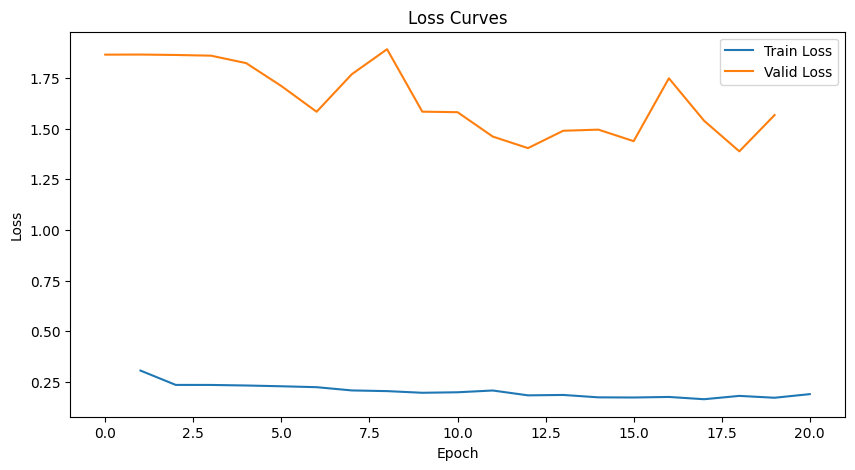

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label="Train Loss")
plt.plot(valid_loss_history, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

In [34]:
torch.save(model.state_dict(), f"{model_name}_interp+nn_model.pth")

In [45]:
model.load_state_dict(torch.load(f"{model_name}_interp+nn_best_model_classify.pth",map_location=device))

<All keys matched successfully>

In [46]:
test_loss = 0
test_classify_loss=0
labels=[]
preds=[]
for (input_seq, ts, spline_preds), (target_idx, target_seq, target_mask), emotion in test_loader:
    # Move inputs to selected device
    input_seq = input_seq.to(device)
    ts = ts.squeeze(0).to(device)

    emotion = le.transform(emotion)
    labels.append(emotion)

    emotion = torch.tensor(emotion, dtype=torch.long,device=device)

    target_seq, target_mask = target_seq.squeeze(0).to(device), target_mask.squeeze(0).to(device)
    target_idx = target_idx.squeeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output,emotion_prob = model(input_seq)
        output = output.squeeze(0)[target_idx]
        #output = model(coeffs,ts, target_ts)
        loss = criterion(output[target_mask], target_seq[target_mask])
        test_loss += loss.item()
        test_classify_loss += criterion2(emotion_prob,emotion).item()
        preds.append(emotion_prob.argmax(-1).item())
test_loss /= len(test_loader)
test_classify_loss /= len(test_loader)

print(f"Test Loss: {test_loss}, Test Classify Loss: {test_classify_loss}")
print(f"Accuracy:{accuracy_score(labels,preds)}")

Test Loss: 0.10396894626319408, Test Classify Loss: 1.6496093057923846
Accuracy:0.3333333333333333


Text(0.5, 1.0, 'Confusion Matrix for XGBoost Classifier')

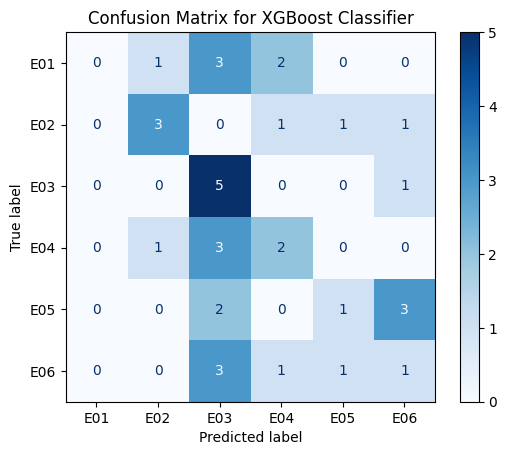

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for XGBoost Classifier")